In [1]:
!pip install editdistance datasets

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Reshape, Dense,
    LSTM, Bidirectional, BatchNormalization, Permute
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import Sequence
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import os

In [3]:
from datasets import load_dataset

# Load the IAM-line dataset
ds = load_dataset("Teklia/IAM-line")

# Split into three parts
train_data = ds['train']        # used to train
validate_data = ds['validation'] # used to tune
test_data = ds['test']           # used to evaluate final model

print(f"Train size: {len(train_data)}")
print(f"Validation size: {len(validate_data)}")
print(f"Test size: {len(test_data)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train.parquet:   0%|          | 0.00/167M [00:00<?, ?B/s]

data/validation.parquet:   0%|          | 0.00/24.7M [00:00<?, ?B/s]

data/test.parquet:   0%|          | 0.00/73.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6482 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/976 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2915 [00:00<?, ? examples/s]

Train size: 6482
Validation size: 976
Test size: 2915


{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=L size=2467x128 at 0x7D3DD21BC170>, 'text': 'put down a resolution on the subject'}
Image size (W x H): (2467, 128)
Text label: put down a resolution on the subject


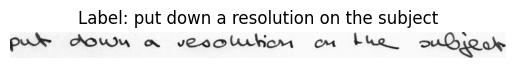

In [4]:
# first sample
print(train_data[0])

#image and its label
sample = train_data[0]
print(f"Image size (W x H): {sample['image'].size}")
print(f"Text label: {sample['text']}")

# Display the image
plt.imshow(sample['image'], cmap='gray')
plt.title(f"Label: {sample['text']}")
plt.axis('off')
plt.show()

In [5]:
# We need to know the range of image sizes in training data
# so we can pick a standard height and compute the max width after resizing

def get_dimension_stats(dataset):
    max_w, max_h = 0, 0
    min_w, min_h = float('inf'), float('inf')

    for item in dataset:
        w, h = item['image'].size
        max_w = max(max_w, w)
        max_h = max(max_h, h)
        min_w = min(min_w, w)
        min_h = min(min_h, h)

    return max_w, max_h, min_w, min_h

max_w, max_h, min_w, min_h = get_dimension_stats(train_data)
print(f"Width  → min: {min_w}, max: {max_w}")
print(f"Height → min: {min_h}, max: {max_h}")

Width  → min: 184, max: 5027
Height → min: 128, max: 128


In [6]:
# We fix height at 64 pixels
TARGET_HEIGHT = 64

# after resizing everything to height=64 (maintaining aspect ratio),
# what's the widest any image becomes? That becomes our standard width.

max_resized_width = 0

for item in train_data:
    orig_w, orig_h = item['image'].size
    aspect_ratio = orig_w / orig_h
    new_w = int(TARGET_HEIGHT * aspect_ratio)
    max_resized_width = max(max_resized_width, new_w)

MAX_WIDTH = max_resized_width

print(f"Target height: {TARGET_HEIGHT}")
print(f"Max width after resize (padding target): {MAX_WIDTH}")

Target height: 64
Max width after resize (padding target): 2513


In [7]:
def preprocess_image(image_pil, target_height, max_width):
    image_np = np.array(image_pil)

    if len(image_np.shape) == 3:
        image_np = cv2.cvtColor(image_np, cv2.COLOR_RGB2GRAY)

    orig_h, orig_w = image_np.shape

    aspect_ratio = orig_w / orig_h
    new_w = int(target_height * aspect_ratio)
    resized = cv2.resize(image_np, (new_w, target_height), interpolation=cv2.INTER_LINEAR)

    # Applying slight Gaussian blur to reduce noise
    # Handwritten images sometimes have ink bleed or scan artifacts
    # Blur smooths these out so the model focuses on stroke shape, not noise
    resized = cv2.GaussianBlur(resized, (3, 3), 0)

    pad_amount = max_width - new_w
    if pad_amount < 0:
        resized = cv2.resize(resized, (max_width, target_height))
    else:
        resized = cv2.copyMakeBorder(resized, 0, 0, 0, pad_amount,
                                     cv2.BORDER_CONSTANT, value=255)

    # Invert the image (black background, white strokes) ---
    # CNNs learn better when the "signal" (ink strokes) is bright (255)
    resized = cv2.bitwise_not(resized)

    return resized

Original size: (2467, 128)
Processed shape: (64, 2513)
Label: put down a resolution on the subject


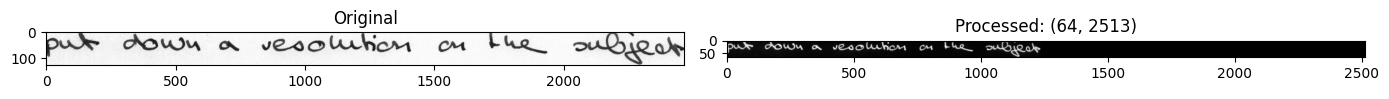

In [8]:
# Test on first training image
sample_img = train_data[0]['image']
processed = preprocess_image(sample_img, TARGET_HEIGHT, MAX_WIDTH)

print(f"Original size: {sample_img.size}")       # (W, H)
print(f"Processed shape: {processed.shape}")      # (H, W)
print(f"Label: {train_data[0]['text']}")

# Display original vs processed
fig, axes = plt.subplots(1, 2, figsize=(14, 3))
axes[0].imshow(sample_img, cmap='gray')
axes[0].set_title("Original")
axes[1].imshow(processed, cmap='gray')
axes[1].set_title(f"Processed: {processed.shape}")
plt.tight_layout()
plt.show()

In [9]:
# Applying preprocess_image to every image in all 3 splits


print("Preprocessing train images...")
train_images = np.array([preprocess_image(item['image'], TARGET_HEIGHT, MAX_WIDTH) for item in train_data])
train_texts = np.array([item['text'] for item in train_data])

print("Preprocessing validation images...")
val_images = np.array([preprocess_image(item['image'], TARGET_HEIGHT, MAX_WIDTH) for item in validate_data])
val_texts = np.array([item['text'] for item in validate_data])

print("Preprocessing test images...")
test_images = np.array([preprocess_image(item['image'], TARGET_HEIGHT, MAX_WIDTH) for item in test_data])
test_texts = np.array([item['text'] for item in test_data])

print(f"Train images shape: {train_images.shape}")    # (6482, 64, MAX_WIDTH)
print(f"Val images shape:   {val_images.shape}")
print(f"Test images shape:  {test_images.shape}")

Preprocessing train images...
Preprocessing validation images...
Preprocessing test images...
Train images shape: (6482, 64, 2513)
Val images shape:   (976, 64, 2513)
Test images shape:  (2915, 64, 2513)


In [10]:
# Collect every unique character from ALL training labels
all_chars = set()
for text in train_texts:
    for char in text:
        all_chars.add(char)

# Sort so the mapping is always consistent (same order every run)
vocabulary = sorted(list(all_chars))

# Add a special [PAD] token at the end
# This is used to pad short labels to a fixed length
if '[PAD]' not in vocabulary:
    vocabulary.append('[PAD]')

# Create two-way lookup dictionaries
char_to_num = {char: idx for idx, char in enumerate(vocabulary)}
num_to_char = {idx: char for idx, char in enumerate(vocabulary)}

vocab_size = len(vocabulary)
pad_token_id = char_to_num['[PAD]']   # index of the padding token

print(f"Vocabulary size: {vocab_size}")
print(f"Characters: {vocabulary}")
print(f"PAD token id: {pad_token_id}")

Vocabulary size: 80
Characters: [' ', '!', '"', '#', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '[PAD]']
PAD token id: 79


In [11]:
# Finding the longest text in training set — all labels will be padded to this length
max_text_len = max(len(text) for text in train_texts)
print(f"Longest text in training set: {max_text_len} characters")

def encode_text(text, char_to_num, max_len, pad_id):
    # Convert each character to its number
    encoded = [char_to_num.get(char, pad_id) for char in text]

    # If text is shorter than max_len, pad with pad_id
    if len(encoded) < max_len:
        encoded += [pad_id] * (max_len - len(encoded))
    else:
        # If longer, just cut it (rare edge case)
        encoded = encoded[:max_len]

    return encoded

# Encode all splits
train_labels = np.array([encode_text(t, char_to_num, max_text_len, pad_token_id) for t in train_texts])
val_labels   = np.array([encode_text(t, char_to_num, max_text_len, pad_token_id) for t in val_texts])
test_labels  = np.array([encode_text(t, char_to_num, max_text_len, pad_token_id) for t in test_texts])

print(f"Train labels shape: {train_labels.shape}")  # (6482, max_text_len)
print(f"Sample encoding of '{train_texts[0]}': {train_labels[0][:10]}...")

Longest text in training set: 80 characters
Train labels shape: (6482, 80)
Sample encoding of 'put down a resolution on the subject': [68 73 72  0 56 67 75 66  0 53]...


In [12]:
def decode_text(encoded, num_to_char):
    # Convert numbers back to characters, skip PAD tokens
    return ''.join([num_to_char[n] for n in encoded if num_to_char.get(n) != '[PAD]'])

# Test: encode then decode should give back original text
original = train_texts[0]
decoded  = decode_text(train_labels[0], num_to_char)

print(f"Original : '{original}'")
print(f"Decoded  : '{decoded}'")
print(f"Match    : {original == decoded}")

Original : 'put down a resolution on the subject'
Decoded  : 'put down a resolution on the subject'
Match    : True


In [13]:
def augment_image(image_np):
    h, w = image_np.shape
    augmented = image_np.copy()

    # --- Keep from original: rotation + translation + scale ---
    angle  = np.random.uniform(-2, 2)
    tx     = np.random.uniform(-0.05 * w, 0.05 * w)
    ty     = np.random.uniform(-0.05 * h, 0.05 * h)
    scale  = np.random.uniform(0.9, 1.1)
    M      = cv2.getRotationMatrix2D((w/2, h/2), angle, scale)
    M[0,2] += tx
    M[1,2] += ty
    augmented = cv2.warpAffine(augmented, M, (w, h), borderValue=0)
    # Note: borderValue=0 (black) because we inverted the image

    # Simulates different pen pressures and paper textures
    if np.random.rand() < 0.4:
        noise = np.random.normal(0, 8, augmented.shape).astype(np.int16)
        augmented = np.clip(augmented.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    # Random brightness adjustment
    if np.random.rand() < 0.4:
        factor = np.random.uniform(0.8, 1.2)
        augmented = np.clip(augmented.astype(np.float32) * factor, 0, 255).astype(np.uint8)
    # Simulates thin vs thick pen strokes
    if np.random.rand() < 0.3:
        kernel = np.ones((1, 2), np.uint8)
        if np.random.rand() < 0.5:
            augmented = cv2.dilate(augmented, kernel, iterations=1)   # thicker strokes
        else:
            augmented = cv2.erode(augmented, kernel, iterations=1)    # thinner strokes

    return augmented

In [14]:
# Handwriting OCR: variable output length → CTC loss

class CTCLayer(tf.keras.layers.Layer):
    def __init__(self, name=None, **kwargs):
        super().__init__(name=name, **kwargs)
        self.loss_fn = tf.keras.backend.ctc_batch_cost

    def call(self, inputs):
        # Unpack inputs: true labels, model predictions, lengths
        labels, y_pred, input_length, label_length = inputs

        input_length = tf.cast(input_length, tf.int32)
        label_length = tf.cast(label_length, tf.int32)

        # Calculate CTC loss and add it to the model's loss
        loss = self.loss_fn(labels, y_pred, input_length, label_length)
        self.add_loss(loss)

        # Return predictions (not loss) so we can use them during inference
        return y_pred

In [15]:
from tensorflow.keras.layers import GRU
CNN_OUTPUT_WIDTH = MAX_WIDTH // 8   # 3 poolings that affect width
CNN_OUTPUT_HEIGHT = TARGET_HEIGHT // 16  # 4 poolings affect height

print(f"CNN output width (sequence length for RNN): {CNN_OUTPUT_WIDTH}")
print(f"CNN output height (flattened into features): {CNN_OUTPUT_HEIGHT}")

# --- Input ---
input_img = Input(shape=(TARGET_HEIGHT, MAX_WIDTH, 1), name='image_input')

# --- CNN Block 1: detect basic edges and strokes ---
x = Conv2D(32, (3,3), padding='same', activation='relu')(input_img)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)   # height: 64→32, width: MAX_WIDTH→MAX_WIDTH/2

# --- CNN Block 2: detect character parts ---
x = Conv2D(64, (3,3), padding='same', activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)   # height: 32→16, width: /2 again

# --- CNN Block 3: detect whole character shapes ---
x = Conv2D(128, (3,3), padding='same', activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x)   # height: 16→8, width: /2 again

# --- CNN Block 4: high-level features, preserve width for sequence ---
x = Conv2D(256, (3,3), padding='same', activation='relu')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 1))(x)   # height: 8→4, width stays same! (important)

# --- Reshape: convert 2D feature map into a sequence ---
# Currently shape is (batch, height, width, channels)
# RNN needs shape (batch, timesteps, features)
# So we make each "column" of the feature map one timestep
x = Permute((2, 1, 3))(x)                                          # (batch, width, height, channels)
x = Reshape((CNN_OUTPUT_WIDTH, CNN_OUTPUT_HEIGHT * 256))(x)        # (batch, width, height*channels)

# Compress features before RNN to reduce computation
x = Dense(128, activation='relu')(x)

x = Bidirectional(GRU(256, return_sequences=True, dropout=0.25))(x)
x = Bidirectional(GRU(256, return_sequences=True, dropout=0.25))(x)
x = Dense(256, activation='relu')(x)

# --- Output: for each timestep, predict probability of each character ---
# +1 is for the CTC blank token (a special "nothing here" symbol)
output = Dense(vocab_size + 1, activation='softmax', name='dense_output')(x)

# --- CTC Inputs (needed only during training, not inference) ---
labels_input  = Input(name='labels',       shape=(max_text_len,), dtype='int32')
input_len     = Input(name='input_length', shape=(1,),            dtype='int32')
label_len     = Input(name='label_length', shape=(1,),            dtype='int32')

# Attach CTC loss layer
ctc_out = CTCLayer(name='ctc_loss')([labels_input, output, input_len, label_len])

# Final training model
model_for_training = Model(
    inputs=[input_img, labels_input, input_len, label_len],
    outputs=ctc_out
)

model_for_training.summary()

CNN output width (sequence length for RNN): 314
CNN output height (flattened into features): 4


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 64, 2513,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 2513,  │        320 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 2513,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 1256,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 1256,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 1256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 628,   │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 628,   │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 628,   │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 8, 314,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 8, 314,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 314,    │      1,024 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 4, 314,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute (Permute)   │ (None, 314, 4,    │          0 │ max_pooling2d_3[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 314, 1024) │          0 │ permute[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 314, 128)  │    131,200 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 314, 512)  │    592,896 │ dense[0][0]       │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,448,721 (9.34 MB)

 Trainable params: 2,447,761 (9.34 MB)

 Non-trainable params: 960 (3.75 KB)

In [16]:
class DataGenerator(Sequence):
    def __init__(self, images, labels, batch_size, augment=False):
        self.images = images
        self.labels = labels
        self.batch_size = batch_size
        self.augment = augment
        # Create shuffled index list
        self.indices = np.arange(len(images))
        np.random.shuffle(self.indices)

    def __len__(self):
        # How many batches per epoch
        return int(np.ceil(len(self.images) / self.batch_size))

    def __getitem__(self, idx):
        # Get indices for this batch
        batch_idx = self.indices[idx * self.batch_size : (idx+1) * self.batch_size]
        batch_size = len(batch_idx)

        # Fetch images and labels for this batch
        batch_images = self.images[batch_idx].copy()
        batch_labels = self.labels[batch_idx].astype(np.int32)

        # Apply augmentation randomly (only for training)
        if self.augment:
            batch_images = np.array([
                augment_image(img) if np.random.rand() < 0.5 else img
                for img in batch_images
            ])

        # Normalize pixels: 0-255 → 0.0-1.0 (same as captcha!)
        # Reshape to add channel dimension: (H, W) → (H, W, 1)
        batch_images = batch_images.astype(np.float32) / 255.0
        batch_images = batch_images.reshape(-1, TARGET_HEIGHT, MAX_WIDTH, 1)

        # input_length: how many timesteps the CNN outputs (same for all images)
        input_length = np.full((batch_size, 1), CNN_OUTPUT_WIDTH, dtype=np.int32)

        # label_length: actual character count (excluding PAD tokens)
        label_length = np.array(
            [np.sum(label != pad_token_id) for label in batch_labels],
            dtype=np.int32
        ).reshape(-1, 1)

        # Pack everything the model needs
        inputs = {
            'image_input' : batch_images,
            'labels'      : batch_labels,
            'input_length': input_length,
            'label_length': label_length
        }

        # CTC model doesn't use a separate output target — return zeros
        outputs = np.zeros(batch_size)

        return inputs, outputs

    def on_epoch_end(self):
        # Reshuffle after every epoch so batches are different each time
        np.random.shuffle(self.indices)


BATCH_SIZE = 32

train_gen = DataGenerator(train_images, train_labels, BATCH_SIZE, augment=True)
val_gen   = DataGenerator(val_images,   val_labels,   BATCH_SIZE, augment=False)
test_gen  = DataGenerator(test_images,  test_labels,  BATCH_SIZE, augment=False)

print(f"Train batches: {len(train_gen)}")
print(f"Val batches:   {len(val_gen)}")
print(f"Test batches:  {len(test_gen)}")

Train batches: 203
Val batches:   31
Test batches:  92


In [17]:
#if we've already trained and saved the model,
# skip training and load directly. Saves hours of retraining!

model_path = 'best_htr_model.keras'
already_trained = os.path.exists(model_path)

print(f"Model already trained and saved: {already_trained}")

Model already trained and saved: False


In [18]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
def train_model():
    # 1. NEW: Define the Drive path inside the function
    model_path = '/content/drive/MyDrive/best_htr_model.keras'

    model_for_training.compile(optimizer=Adam(learning_rate=0.001))

    # Stop training early if val_loss doesn't improve for 10 epochs
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    # If val_loss plateaus, reduce learning rate automatically
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=1e-5
    )

    # 2. UPDATED: Ensure it saves to the Drive path
    checkpoint = ModelCheckpoint(
        filepath=model_path, # Now pointing to Drive
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    )

    print("Starting training...")

    # After you run this cell to define the function,
    # use the resume code block I gave you previously to actually call the training.

In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# 1. Define the path
model_path = '/content/drive/MyDrive/best_htr_model.keras'

# 2. Define the Callbacks (so the code can find them)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-5)
checkpoint = ModelCheckpoint(filepath=model_path, monitor='val_loss', save_best_only=True, verbose=1)

# 3. Load or Start Fresh
if os.path.exists(model_path):
    print("--- Checkpoint found! Resuming from Epoch 43 ---")
    model_for_training = tf.keras.models.load_model(
        model_path,
        custom_objects={'CTCLayer': CTCLayer}
    )
    start_epoch = 42
else:
    print("--- No checkpoint found. Starting from Epoch 0 ---")
    start_epoch = 0

# 4. Compile and Run
model_for_training.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))

model_for_training.fit(
    train_gen,
    validation_data=val_gen,
    epochs=100,
    initial_epoch=start_epoch,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

--- Checkpoint found! Resuming from Epoch 43 ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 43/100
  5/203 ━━━━━━━━━━━━━━━━━━━━ 1:21:09 25s/step - loss: 554.9486

In [19]:
# Load the full training model from disk
loaded_model = tf.keras.models.load_model(
    model_path,
    custom_objects={'CTCLayer': CTCLayer},  # needed because CTCLayer is our custom class
    compile=False
)

print("Model loaded successfully!")

# --- Build Inference Model ---
# The training model has 4 inputs (image + labels + lengths) — needed for CTC loss
# For prediction, we ONLY need the image input and the character probability output
# So we extract just those two parts

inference_model = Model(
    inputs=loaded_model.input[0],                        # just the image input
    outputs=loaded_model.get_layer('dense_output').output # character probabilities
)

print("Inference model ready!")
inference_model.summary()

ValueError: File not found: filepath=best_htr_model.keras. Please ensure the file is an accessible `.keras` zip file.

In [ ]:
def decode_predictions(pred, num_to_char, beam_width=5):
    input_len = np.ones(pred.shape[0]) * pred.shape[1]

    decoded = tf.keras.backend.ctc_decode(
        pred,
        input_length=input_len,
        greedy=False,          # switch to beam search
        beam_width=beam_width  # explore top 5 paths at each step
    )[0][0]

    results = []
    for sequence in decoded.numpy():
        chars = []
        prev = -1
        for token in sequence:
            if token != -1 and token != len(num_to_char) and token != prev:
                chars.append(num_to_char.get(token, ''))
            prev = token
        results.append(''.join(chars))

    return results

In [ ]:
def predict_from_pil(image_pil, inference_model):
    # Step 1: preprocess the image exactly as training data
    processed = preprocess_image(image_pil, TARGET_HEIGHT, MAX_WIDTH)

    # Step 2: normalize to 0-1 range
    img = processed.astype(np.float32) / 255.0

    # Step 3: add batch dimension and channel dimension
    img = np.expand_dims(img, axis=0)   # (1, H, W)
    img = np.expand_dims(img, axis=-1)  # (1, H, W, 1)

    # Step 4: get raw character probabilities from model
    pred = inference_model.predict(img, verbose=0)

    # Step 5: decode probabilities into actual text
    text = decode_predictions(pred, num_to_char)

    return text[0]

In [ ]:
# Pick any sample from test data
sample_idx = 100
sample_image = test_data[sample_idx]['image']
true_label   = test_data[sample_idx]['text']

# Predict
predicted = predict_from_pil(sample_image, inference_model)

# Display
plt.figure(figsize=(12, 3))
plt.imshow(sample_image, cmap='gray')
plt.title(f"True: '{true_label}'\nPredicted: '{predicted}'")
plt.axis('off')
plt.show()

print(f"True label : '{true_label}'")
print(f"Predicted  : '{predicted}'")

In [ ]:
import requests
from io import BytesIO

def predict_from_url(url, inference_model):
    try:
        # Download image from the internet
        response = requests.get(url)
        response.raise_for_status()

        # Open as PIL and convert to grayscale (same as training data)
        image_pil = Image.open(BytesIO(response.content)).convert('L')

        # Predict using our function
        predicted = predict_from_pil(image_pil, inference_model)
        return predicted, image_pil

    except Exception as e:
        print(f"Error: {e}")
        return "", None


url = "https://github.com/Belval/TextRecognitionDataGenerator/blob/master/samples/1.jpg?raw=true"
predicted_text, img = predict_from_url(url, inference_model)

if img:
    plt.figure(figsize=(10, 3))
    plt.imshow(img, cmap='gray')
    plt.title(f"Predicted: '{predicted_text}'")
    plt.axis('off')
    plt.show()

print(f"Predicted text: '{predicted_text}'")

In [ ]:
import editdistance

def calculate_cer(true_text, pred_text):
    # CER = character-level edit distance / number of true characters
    # Edit distance = minimum insertions + deletions + substitutions to match
    if len(true_text) == 0:
        return 0.0 if len(pred_text) == 0 else 1.0
    return editdistance.eval(list(true_text), list(pred_text)) / len(true_text)

def calculate_wer(true_text, pred_text):
    # WER = word-level edit distance / number of true words
    true_words = true_text.split()
    pred_words = pred_text.split()
    if len(true_words) == 0:
        return 0.0 if len(pred_words) == 0 else 1.0
    return editdistance.eval(true_words, pred_words) / len(true_words)


def evaluate(generator, inference_model, num_to_char, num_batches=20):
    all_true, all_pred = [], []

    for i in range(min(num_batches, len(generator))):
        batch_inputs, _ = generator[i]
        batch_images  = batch_inputs['image_input']
        batch_labels  = batch_inputs['labels']

        raw_preds  = inference_model.predict(batch_images, verbose=0)
        pred_texts = decode_predictions(raw_preds, num_to_char)
        true_texts = [decode_text(label, num_to_char) for label in batch_labels]

        all_true.extend(true_texts)
        all_pred.extend(pred_texts)
        print(f"Batch {i+1}/{num_batches} done")

    cer_scores = [calculate_cer(t, p) for t, p in zip(all_true, all_pred)]
    wer_scores = [calculate_wer(t, p) for t, p in zip(all_true, all_pred)]

    avg_cer = np.mean(cer_scores) * 100
    avg_wer = np.mean(wer_scores) * 100

    print(f"\nAverage CER: {avg_cer:.2f}%")
    print(f"Average WER: {avg_wer:.2f}%")

    #Plot CER distribution
    plt.figure(figsize=(10, 4))
    plt.hist([s * 100 for s in cer_scores], bins=30, color='steelblue', edgecolor='white')
    plt.axvline(avg_cer, color='red', linestyle='--', label=f'Mean CER: {avg_cer:.1f}%')
    plt.xlabel('Character Error Rate (%)')
    plt.ylabel('Number of Samples')
    plt.title('CER Distribution on Test Set')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- DIFFERENCE: Show best AND worst predictions side by side ---
    sorted_by_cer = sorted(zip(cer_scores, all_true, all_pred))

    print("\n  Best Predictions (lowest CER):")
    for cer, true, pred in sorted_by_cer[:3]:
        print(f"  CER: {cer*100:.1f}%  |  True: '{true}'  |  Pred: '{pred}'")

    print("\n  Worst Predictions (highest CER):")
    for cer, true, pred in sorted_by_cer[-3:]:
        print(f"  CER: {cer*100:.1f}%  |  True: '{true}'  |  Pred: '{pred}'")

evaluate(test_gen, inference_model, num_to_char, num_batches=20)

In [ ]:


NUM_SAMPLES = 15   # doing 15 to be safe (requirement is 10+)
results = []

print(f"Running inference on {NUM_SAMPLES} test samples...")

for i in range(NUM_SAMPLES):
    sample_img  = test_data[i]['image']
    true_text   = test_data[i]['text']
    pred_text   = predict_from_pil(sample_img, inference_model)

    cer = calculate_cer(true_text, pred_text)
    wer = calculate_wer(true_text, pred_text)

    results.append({
        'idx': i, 'true': true_text,
        'predicted': pred_text,
        'cer': cer, 'wer': wer
    })

    print(f"[{i+1}/{NUM_SAMPLES}] True: '{true_text}' | Pred: '{pred_text}' | CER: {cer:.3f}")

# text file
with open('predictions_report.txt', 'w', encoding='utf-8') as f:
    f.write("IAM-line OCR — Predictions Report\n")
    f.write("Model : CNN + BiGRU + CTC\n")
    f.write("Dataset: Teklia/IAM-line (HuggingFace)\n")
    f.write("=" * 60 + "\n\n")

    for r in results:
        f.write(f"Image {r['idx']+1} (test_data[{r['idx']}])\n")
        f.write(f"  Ground Truth : {r['true']}\n")
        f.write(f"  Predicted    : {r['predicted']}\n")
        f.write(f"  CER          : {r['cer']:.4f}\n")
        f.write(f"  WER          : {r['wer']:.4f}\n")
        f.write(f"  Quality      : {'Good' if r['cer'] < 0.2 else 'Needs improvement'}\n\n")

    mean_cer = np.mean([r['cer'] for r in results]) * 100
    mean_wer = np.mean([r['wer'] for r in results]) * 100
    f.write("-" * 60 + "\n")
    f.write(f"Mean CER over {NUM_SAMPLES} samples: {mean_cer:.2f}%\n")
    f.write(f"Mean WER over {NUM_SAMPLES} samples: {mean_wer:.2f}%\n")



In [ ]:
import zipfile

with zipfile.ZipFile('submission.zip', 'w') as zf:
    zf.write('DLPRO.ipynb')
    zf.write('predictions_report.txt')

print("submission.zip created")
